In [1]:
!pip install -q datasets

from datasets import load_dataset, concatenate_datasets
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    accuracy_score, f1_score, roc_curve, roc_auc_score
)

In [2]:
ag_news = load_dataset("ag_news")

def convertir_a_binario(elemento):
    return {"label": 1 if elemento["label"] == 1 else 0}

ag_news_binario = ag_news.map(convertir_a_binario)

full_dataset = concatenate_datasets([
    ag_news_binario["train"],
    ag_news_binario["test"]
])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [3]:
SEMILLA = 42

division_1 = full_dataset.train_test_split(test_size=0.2, seed=SEMILLA, shuffle=True)
train_set = division_1["train"]
temp_set = division_1["test"]

division_2 = temp_set.train_test_split(test_size=0.5, seed=SEMILLA, shuffle=True)
dev_set = division_2["train"]
test_set = division_2["test"]

In [4]:
sports_lexicon = {
    'goal', 'stadium', 'match', 'player', 'players', 'team', 'teams',
    'coach', 'league', 'champion', 'championship', 'score', 'scored',
    'win', 'winner', 'winning', 'tournament', 'olympics', 'football',
    'soccer', 'basketball', 'tennis', 'golf', 'baseball', 'hockey',
    'game', 'games', 'race', 'cup', 'final', 'season', 'record'
}

non_sports_lexicon = {
    'government', 'stock', 'market', 'election', 'policy', 'economy',
    'technology', 'science', 'research', 'company', 'percent', 'growth',
    'president', 'minister', 'law', 'court', 'vote', 'bill'
}

emphasis_lexicon = {
    'win', 'lose', 'won', 'lost', 'victory', 'defeat', 'amazing',
    'incredible', 'surprise', 'shock', 'stunning', 'historic'
}

pronouns = {'i', 'me', 'my', 'we', 'us', 'our', 'you', 'your'}

In [5]:
def extract_features(texto):
    tokens = texto.lower().split()
    longitud = len(tokens) if len(tokens) > 0 else 1

    x1 = sum(1 for w in tokens if w in sports_lexicon)
    x2 = sum(1 for w in tokens if w in non_sports_lexicon)
    x3 = sum(1 for w in tokens if w in emphasis_lexicon)
    x4 = sum(1 for w in tokens if w in pronouns)
    x5 = 1 if "!" in texto else 0
    x6 = math.log(longitud)

    return np.array([x1, x2, x3, x4, x5, x6])

In [6]:
X_train = np.array([extract_features(item["text"]) for item in train_set])
X_dev = np.array([extract_features(item["text"]) for item in dev_set])
X_test = np.array([extract_features(item["text"]) for item in test_set])

y_train = np.array([item["label"] for item in train_set])
y_dev = np.array([item["label"] for item in dev_set])
y_test = np.array([item["label"] for item in test_set])

In [7]:
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0) + 1e-8

X_train_norm = (X_train - train_mean) / train_std
X_dev_norm = (X_dev - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predecir(X, theta):
    return (sigmoid(X @ theta) >= 0.5).astype(int)

In [9]:
ETA = 0.1
EPOCHS = 20

n_features = X_train_norm.shape[1]
theta = np.zeros(n_features)

loss_history = []
theta_history = []

for epoch in range(EPOCHS):
    total_loss = 0.0
    
    for x_i, y_i in zip(X_train_norm, y_train):
        z = np.dot(theta, x_i)
        y_hat = sigmoid(z)
        
        loss = -(y_i * np.log(y_hat + 1e-8) + (1 - y_i) * np.log(1 - y_hat + 1e-8))
        total_loss += loss
        
        error = y_i - y_hat
        theta += ETA * error * x_i
    
    avg_loss = total_loss / len(X_train_norm)
    
    loss_history.append(avg_loss)
    theta_history.append(theta.copy())

theta_history = np.array(theta_history)

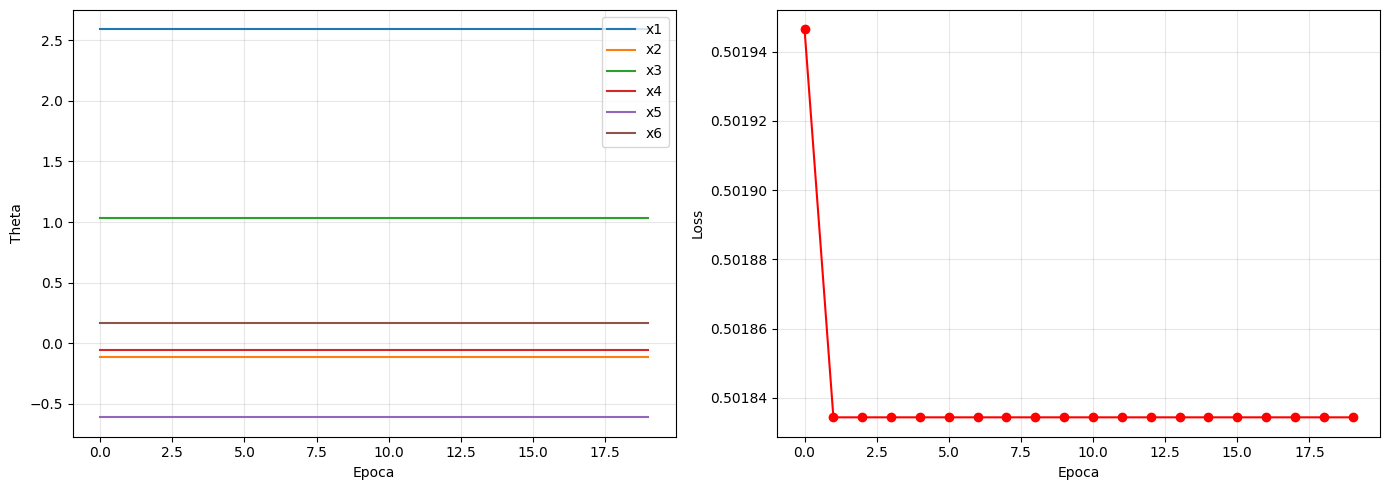

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feature_names = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']

for j in range(n_features):
    axes[0].plot(theta_history[:, j], label=feature_names[j])
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Theta")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history, marker='o', color='red')
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
y_dev_pred = predecir(X_dev_norm, theta)
cm_dev = confusion_matrix(y_dev, y_dev_pred)

precision_dev = precision_score(y_dev, y_dev_pred)
recall_dev = recall_score(y_dev, y_dev_pred)
f1_dev = f1_score(y_dev, y_dev_pred)
accuracy_dev = accuracy_score(y_dev, y_dev_pred)

print("=== DEV SET ===")
print(f"Confusion Matrix:\n{cm_dev}")
print(f"Accuracy: {accuracy_dev:.4f} | Precision: {precision_dev:.4f} | Recall: {recall_dev:.4f} | F1: {f1_dev:.4f}")

=== DEV SET ===
Confusion Matrix:
[[8636  935]
 [ 950 2239]]
Accuracy: 0.8523 | Precision: 0.7054 | Recall: 0.7021 | F1: 0.7038


In [12]:
y_test_pred = predecir(X_test_norm, theta)
cm_test = confusion_matrix(y_test, y_test_pred)

precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

print("=== TEST SET ===")
print(f"Confusion Matrix:\n{cm_test}")
print(f"Accuracy: {accuracy_test:.4f} | Precision: {precision_test:.4f} | Recall: {recall_test:.4f} | F1: {f1_test:.4f}")

=== TEST SET ===
Confusion Matrix:
[[8501 1000]
 [1029 2230]]
Accuracy: 0.8410 | Precision: 0.6904 | Recall: 0.6843 | F1: 0.6873


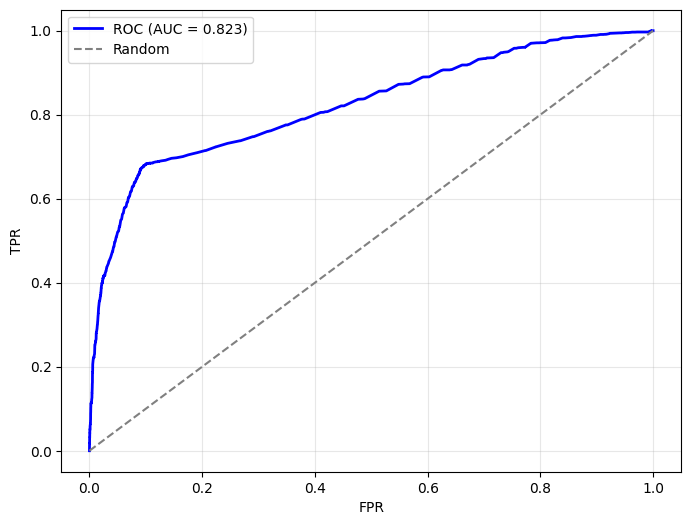

AUC: 0.8231


In [13]:
y_test_probs = sigmoid(X_test_norm @ theta)
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
auc_score = roc_auc_score(y_test, y_test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC: {auc_score:.4f}")

In [14]:
ejemplos = [
    "The football team won the championship in a stunning overtime victory.",
    "Stock markets fell today following new economic policy announcements.",
    "Tennis star advances to the final round after hard fought match.",
    "Technology company released quarterly earnings with record profits."
]

for i, texto in enumerate(ejemplos):
    features = extract_features(texto)
    features_norm = (features - train_mean) / train_std
    prob = sigmoid(np.dot(theta, features_norm))
    pred = "DEPORTES" if prob >= 0.5 else "NO DEPORTES"
    print(f"{i+1}. {pred} ({prob:.4f})")

1. DEPORTES (1.0000)
2. NO DEPORTES (0.0726)
3. DEPORTES (0.9806)
4. DEPORTES (0.5955)
